# CANADA

# Packages

In [3]:
import itertools
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import os
import pandas as pd
import pickle
import seaborn as sns
from tqdm import tqdm

from sklearn.decomposition import PCA
from scipy.stats.mstats import zscore

# Directories

In [4]:
INPUT = 'D:/DDesktop/_work/data/canada/input/'
FEATURECOUNTS = INPUT + 'featureCounts/'

LINCS = INPUT + 'LDS-1481/'
LINCS_DEXP = LINCS + 'LDS-1481_1.0.gctx'
LINCS_GENE_INFO = LINCS + 'GSE92742_Broad_LINCS_gene_info.txt.gz'
LINCS_SIGNATURE_INFO = LINCS + 'GSE92742_Broad_LINCS_sig_info.txt.gz'
VST = INPUT + 'vstCounts/'

STRING = INPUT + 'string/'
STRING_EDGES = STRING + '9606.protein.physical.links.full.v12.0.txt.gz'
STRING_INFO = STRING + '9606.protein.info.v12.0.txt.gz'


OUTPUT = 'D:/DDesktop/_work/data/canada/output/'
TABULAR = OUTPUT + 'tabular/'
CONTEXT = OUTPUT + 'context_graphs/'

# Functions

In [5]:
def chdir(data, sampleclass, genes, gamma=1., sort=True, calculate_sig=False, nnull=10, sig_only=False, norm_vector=True):
	"""
	Calculate the characteristic direction for a gene expression dataset
	
	Input:
		data: numpy.array, is the data matrix of gene expression where rows correspond to genes and columns correspond to samples
		sampleclass: list or numpy.array, labels of the samples, it has to be consist of 0, 1 and 2, with 0 being columns to be excluded, 1 being control and 2 being perturbation
				example: sampleclass = [1,1,1,2,2,2]
		genes: list or numpy.array, row labels for genes 
		gamma: float, regulaized term. A parameter that smooths the covariance matrix and reduces potential noise in the dataset
		sort: bool, whether to sort the output by the absolute value of chdir
		calculate_sig: bool, whether to calculate the significance of characteristic directions
		nnull: int, number of null characteristic directions to calculate for significance
		sig_only: bool, whether to return only significant genes; active only when calculate_sig is True
		norm_vector: bool, whether to return a characteristic direction vector normalized to unit vector
	Output:
		A list of tuples sorted by the absolute value in descending order characteristic directions of genes.
			If calculate_sig is set to True, each tuple contains a third element which is the ratio of characteristic directions to null ChDir
	"""
	
	## check input
	data.astype(float)
	sampleclass = np.array(list(map(int, sampleclass)))
	# masks
	m_non0 = sampleclass != 0
	m1 = sampleclass[m_non0] == 1
	m2 = sampleclass[m_non0] == 2

	if type(gamma) not in [float, int]:
		raise ValueError("gamma has to be a numeric number")
	if set(sampleclass) != set([1,2]) and set(sampleclass) != set([0,1,2]):
		raise ValueError("sampleclass has to be a list whose elements are in only 0, 1 or 2")
	# if m1.sum()<2 or m2.sum()<2:
	# 	raise ValueError("Too few samples to calculate characteristic directions")
	if len(genes) != data.shape[0]:
		raise ValueError("Number of genes does not match the demension of the expression matrix")

	## normalize data
	data = data[:, m_non0]
	data = zscore(data) # standardize for each genes across samples

	## start to compute
	n1 = m1.sum() # number of controls
	n2 = m2.sum() # number of experiments

	## the difference between experiment mean vector and control mean vector.
	meanvec = data[:,m2].mean(axis=1) - data[:,m1].mean(axis=1) 

	## initialize the pca object
	pca = PCA(n_components=None)
	pca.fit(data.T)

	## compute the number of PCs to keep
	cumsum = pca.explained_variance_ratio_ # explained variance of each PC
	keepPC = len(cumsum[cumsum > 0.001]) # number of PCs to keep

	v = pca.components_[0:keepPC].T # rotated data 
	r = pca.transform(data.T)[:,0:keepPC] # transformed data

	dd = ( np.dot(r[m1].T,r[m1]) + np.dot(r[m2].T,r[m2]) ) / float(n1+n2-2) # covariance
	sigma = np.mean(np.diag(dd)) # the scalar covariance

	shrunkMats = np.linalg.inv(gamma*dd + sigma*(1-gamma)*np.eye(keepPC))

	b = np.dot(v, np.dot(np.dot(v.T, meanvec), shrunkMats))

	if norm_vector:
		b /= np.linalg.norm(b) # normalize b to unit vector

	grouped = zip([abs(item) for item in b],b,genes)
	if sort:
		grouped = sorted(grouped,key=lambda x: x[0], reverse=True)


	if not calculate_sig: # return sorted b and genes.
		res = [(item[1],item[2]) for item in grouped]
		return res
	else: # generate a null distribution of chdirs
		nu = n1 + n2 - 2
		y1 = np.random.multivariate_normal(np.zeros(keepPC), dd, nnull).T * np.sqrt(nu / chi2.rvs(nu,size=nnull))
		y2 = np.random.multivariate_normal(np.zeros(keepPC), dd, nnull).T * np.sqrt(nu / chi2.rvs(nu,size=nnull))
		y = y2 - y1 ## y is the null of v

		nullchdirs = []
		for col in y.T:
			bn = np.dot(np.dot(np.dot(v,shrunkMats), v.T), np.dot(col,v.T))
			bn /= np.linalg.norm(bn)
			bn = bn ** 2
			bn.sort()
			bn = bn[::-1] ## sort in decending order
			nullchdirs.append(bn)

		nullchdirs = np.array(nullchdirs).T
		nullchdirs = nullchdirs.mean(axis=1)
		b_s = b ** 2 
		b_s.sort()
		b_s = b_s[::-1] # sorted b in decending order
		relerr = b_s / nullchdirs ## relative error
		# ratio_to_null
		ratios = np.cumsum(relerr)/np.sum(relerr)- np.linspace(1./len(meanvec),1,len(meanvec))
		res = [(item[1],item[2], ratio) for item, ratio in zip(grouped, ratios)] 
		print('Number of significant genes: %s'%(np.argmax(ratios)+1))
		if sig_only:
			return res[0:np.argmax(ratios)+1]
		else:
			return res

def featurecounts_to_tabular(directory: str, file: str) -> pd.DataFrame:
    '''
    Converts featureCounts output from RNAseq quantification pipeline to tabular files to be used for Galaxy analysis.
    '''

    # Import data
    df = pd.read_csv(directory + file, sep = '\t', comment = '#')
    # Extract first and last column
    df = df.iloc[:, [0, -1]]
    # Rename columns
    df.rename(columns = {df.columns[-1] : 'count'}, inplace = True)

    return df

def file_to_list(path):
    '''
    Converts a .txt file to a list
    '''

    with open(f'{path}', 'r', encoding = 'utf-8') as f:
        list_file = [line.strip() for line in f]
    
    return list_file

def list_to_file(path, data):
      '''
      Saves a list or set to a .txt file with no header.
      '''

      with open(path, 'w') as f:
            for item in sorted(data):
                  f.write(f'{item}\n')

def pickle_load(path: str, report: bool = False):
    '''
    Loads pickled data.
    '''

    with open(path, 'rb') as f:
        data = pickle.load(f)

    if report == True:
        if type(data) == nx.Graph:
            num_nodes = len(data.nodes)
            num_edges = len(data.edges)
            print('>> pickle_load')
            print(f'Pickled graph loaded w/ {num_nodes:,} nodes and {num_edges:,} edges')
            print()
        else:
            print('>> pickle_load')
            print(f'Pickled file loaded')
            print()

    return data

def pickle_save(path: str, data, report: bool = False):
    '''
    Pickles data.
    '''

    with open(path, 'wb') as f:
        pickle.dump(data, f)

    if report == True:
        if type(data) == nx.Graph:
            num_nodes = len(data.nodes)
            num_edges = len(data.edges)
            print('>> pickle_save')
            print(f'Graph w/ {num_nodes:,} nodes and {num_edges:,} edges pickled')
        else:
            print('>> pickle_save')
            print(f'Data pickled')
            print()

def vst_landmark_filter(data: pd.DataFrame, landmark_data: pd.DataFrame, filter_column: str) -> pd.DataFrame:
    '''
    Filters VST normalised counts using LINCS landmark gene names.
    '''

    # Get landmark genes
    list_landmark = list(pd.unique(landmark_data[filter_column]))
    # Filter data
    df = data[data[filter_column].isin(list_landmark)]

    ## REPORT
    # Get number of genes pre-filter
    num_genes = len(data)
    # Get number of landmark genes
    num_landmark = len(list_landmark)
    # Get number of genes post-filter
    num_filter = len(pd.unique(df[filter_column]))
    # Percent landmark genes present
    percent_landmark = num_filter / num_landmark * 100
    # Percentage of measured genes
    percent_genes = num_filter / num_genes * 100

    print(f'{percent_landmark:.2f}% landmark genes ({num_filter:,}/{num_landmark:,}) found in data, making up {percent_genes:2f}% of all measured genes ({num_filter:,}/{num_genes:,})')


    return df

# Pre-processing

## featureCounts

In [ ]:
# Get non-summary files as list
list_nsummary = [file for file in os.listdir(FEATURECOUNTS) if 'summary' not in file]
list_samples = list(set([file.split('_L00')[0] for file in list_nsummary]))
num_samples = len(list_samples)

# Iterate through sample IDs
for sample in tqdm(list_samples, desc = 'Merging lane files and converting to .tabular', total = num_samples):
    
    # Get description
    desc = sample.split('_')[1]

    # Load lane files
    df1 = pd.read_csv(FEATURECOUNTS + f'{sample}_L001_featureCounts.txt', sep = '\t', comment = '#')
    df2 = pd.read_csv(FEATURECOUNTS + f'{sample}_L002_featureCounts.txt', sep = '\t', comment = '#')

    # Extract first and last column
    df1 = df1.iloc[:, [0, -1]]
    df2 = df2.iloc[:, [0, -1]]

    # Rename columns
    df1.rename(columns = {df1.columns[1] : 'lane1'}, inplace = True)
    df2.rename(columns = {df2.columns[1] : 'lane2'}, inplace = True)

    # Merge data
    df = pd.merge(df1, df2, how = 'left', on = 'Geneid')
    
    # Sum column
    df['count'] = df['lane1'] + df['lane2']
    # Retain data
    df = df[['Geneid', 'count']]

    # Save as tabular file
    df.to_csv(TABULAR + f'{desc}.tabular', sep = '\t', index = False)

Merging lane files and converting to .tabular: 100%|██████████| 96/96 [01:48<00:00,  1.13s/it]


## LINCS

### General Info

#### `df_lincs_info`

In [73]:
# Load data
df_lincs_info = pd.read_csv(LINCS_SIGNATURE_INFO, sep = '\t')
# Rename columns
df_lincs_info.rename(columns = {'pert_id' : 'perturbagen_id', 'pert_iname' : 'perturbagen_name'}, inplace = True)
# Pickle data
pickle_save(OUTPUT + 'df_lincs_info.pkl', df_lincs_info)
# Show data
df_lincs_info.head()

C:\Users\roman\AppData\Local\Temp\ipykernel_12364\2153237437.py:2: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df_lincs_info = pd.read_csv(LINCS_SIGNATURE_INFO, sep = '\t')


,sig_id,perturbagen_id,perturbagen_name,pert_type,cell_id,pert_dose,pert_dose_unit,pert_idose,pert_time,pert_time_unit,pert_itime,distil_id
0,AML001_CD34_24H:A05,DMSO,DMSO,ctl_vehicle,CD34,0.1,%,0.1 %,24,h,24 h,AML001_CD34_24H_X1_F1B10:A05
1,AML001_CD34_24H:A06,DMSO,DMSO,ctl_vehicle,CD34,0.1,%,0.1 %,24,h,24 h,AML001_CD34_24H_X3_F1B10:A06
2,AML001_CD34_24H:B05,DMSO,DMSO,ctl_vehicle,CD34,0.1,%,0.1 %,24,h,24 h,AML001_CD34_24H_X1_F1B10:B05|AML001_CD34_24H_X...
3,AML001_CD34_24H:B06,DMSO,DMSO,ctl_vehicle,CD34,0.1,%,0.1 %,24,h,24 h,AML001_CD34_24H_X3_F1B10:B06
4,AML001_CD34_24H:BRD-A03772856:0.37037,BRD-A03772856,BRD-A03772856,trt_cp,CD34,0.37037,µM,500 nM,24,h,24 h,AML001_CD34_24H_X1_F1B10:J04|AML001_CD34_24H_X...


### Perturbagen Info

#### `df_lincs_perturbagens`

In [74]:
# Load data
df_lincs_perturbagens = pickle_load(OUTPUT + 'df_lincs_info.pkl')
# Isolate columns
df_lincs_perturbagens = df_lincs_perturbagens[['perturbagen_id', 'perturbagen_name']]
# Remove duplicates
df_lincs_perturbagens.drop_duplicates(inplace = True, ignore_index = True)
# Pickle data
pickle_save(OUTPUT + 'df_lincs_perturbagens.pkl', df_lincs_perturbagens)
# Show data
df_lincs_perturbagens.head()

,perturbagen_id,perturbagen_name
0,DMSO,DMSO
1,BRD-A03772856,BRD-A03772856
2,BRD-A19037878,trichostatin-a
3,BRD-A19500257,geldanamycin
4,BRD-A34037822,KUC107191N


### Gene Info

#### `df_lincs_genes`

In [21]:
# Load gene data
df_lincs_genes = pd.read_csv(LINCS_GENE_INFO, sep = '\t')

# Rename columns
df_lincs_genes.rename(columns = {'pr_gene_id' : 'rid',
                                 'pr_gene_symbol' : 'gene_name',
                                 'pr_gene_title' : 'gene_desc',
                                 'pr_is_lm' : 'landmark',
                                 'pr_is_bing' : 'inferred'}, inplace = True)

# Save data
pickle_save(OUTPUT + 'df_lincs_genes.pkl', df_lincs_genes)

# Show data
df_lincs_genes.head()

,rid,gene_name,gene_desc,landmark,inferred
0,780,DDR1,discoidin domain receptor tyrosine kinase 1,1,1
1,7849,PAX8,paired box 8,1,1
2,2978,GUCA1A,guanylate cyclase activator 1A,0,0
3,2049,EPHB3,EPH receptor B3,0,1
4,2101,ESRRA,estrogen related receptor alpha,0,1


#### `df_lincs_landmark`

In [85]:
# Load df_lincs_genes
df_lincs_landmark = pickle_load(OUTPUT + 'df_lincs_genes.pkl')

# Extract landmark genes
df_lincs_landmark = df_lincs_landmark[df_lincs_landmark['landmark'] == 1]

# Save data
pickle_save(OUTPUT + 'df_lincs_landmark.pkl', df_lincs_landmark)

# Show data
df_lincs_landmark.head()

,rid,gene_name,gene_desc,landmark,inferred
0,780,DDR1,discoidin domain receptor tyrosine kinase 1,1,1
1,7849,PAX8,paired box 8,1,1
25,6193,RPS5,ribosomal protein S5,1,1
43,23,ABCF1,ATP binding cassette subfamily F member 1,1,1
49,9552,SPAG7,sperm associated antigen 7,1,1


## vstCounts

In [87]:
# Load data
df_lincs_landmark = pickle_load(OUTPUT + 'df_lincs_landmark.pkl')

# Get landmark set
set_landmark = set(df_lincs_landmark['gene_name'])

# Iterate through files
for file in os.listdir(VST):
    
    # Print file
    print(file)
    # Get timepoint
    timepoint = file.split('_')[0]

    # Load file
    df = pd.read_csv(VST + file, sep = '\t')
    # Rename column
    df.rename(columns = {df.columns[0] : 'gene_name'}, inplace = True)
    # Get gene set
    set_genes = set(df['gene_name'])
    # Filter data
    df = vst_landmark_filter(data = df, landmark_data = df_lincs_landmark, filter_column = 'gene_name')
    # Save data
    df.to_csv(OUTPUT + f'{timepoint}_vst_landmark.csv', index = False)

    # Get set difference
    set_diff = set_landmark - set_genes
    # Get set intersection
    set_intersect = set_landmark.intersection(set_genes)

# Save mapped landmark genes
list_to_file(OUTPUT + 'mapped_landmark.txt', set_intersect)
# Save unmapped landmark genes
list_to_file(OUTPUT + 'unmapped_landmark.txt', set_diff)

24h_vst.tabular
96.63% landmark genes (945/978) found in data, making up 1.885625% of all measured genes (945/50,116)
6h_vst.tabular
96.63% landmark genes (945/978) found in data, making up 1.885625% of all measured genes (945/50,116)


## Characteristic Direction

In [41]:
# Set treatment list
list_treatment = ['halo', 'paro', 'nita']
# Get file list
list_cd = [file for file in os.listdir(OUTPUT) if 'quantile' in file]

# Initialise all results dataframe
df_cd = pd.DataFrame()

# Iterate through files
for file in tqdm(list_cd, desc = 'Analysing timepoints', total = len(list_cd)):

    # Get timepoint
    timepoint = file.split('_')[0]
    # Load data
    df_file = pd.read_csv(OUTPUT + file, index_col = 0)
    # Get gene list
    list_genes = list(df_file.index)
    
    # Initialise cd data
    df_timepoint = pd.DataFrame()

    # Get vehicle columns
    col_vehicle = [column for column in df_file.columns if 'vehicle' in column]
    
    # Iterate through treatment types
    for treatment in tqdm(list_treatment, desc = 'Analysing treatments', total = len(list_treatment)):
        
        # Get treatment columns
        col_treatment = [column for column in df_file.columns if f'inf_{treatment}' in column]
        # Set relevant columns
        list_cols = col_vehicle + col_treatment
        # Extract data
        df_treatment = df_file[list_cols]
        
        # Run chdir
        cd_result = chdir(data = df_treatment.values,
                          sampleclass = [1,1,1,2,2,2],
                          genes = list_genes)

        # Convert to dataframe
        df_result = pd.DataFrame(cd_result, columns = ['cd', 'gene_name'])
        # Add datatype column
        df_result['datatype'] = 'inf'
        # Add treatment column
        df_result['treatment'] = treatment
        # Concatenate dataframe
        df_timepoint = pd.concat([df_timepoint, df_result])

        # # Get COLO columns
        # col_colo = [column for column in df_file.columns if f'colo_{treatment}' in column]
        # # Set relevant columns
        # list_cols = col_vehicle + col_colo
        # # Extract data
        # df_colo = df_file[list_cols]
        
        # # Run chdir
        # cd_result = chdir(data = df_colo.values,
        #                   sampleclass = [1,1,1,2,2,2],
        #                   genes = list_genes)

        # # Convert to dataframe
        # df_result = pd.DataFrame(cd_result, columns = ['cd', 'gene_name'])
        # # Add datatype column
        # df_result['datatype'] = 'colo'
        # # Add treatment column
        # df_result['treatment'] = treatment
        # # Concatenate dataframe
        # df_timepoint = pd.concat([df_timepoint, df_result])
    
    # Add timepoint column
    df_timepoint['timepoint'] = timepoint
    # Concatenate dataframe
    df_cd = pd.concat([df_cd, df_timepoint])

# Save data
pickle_save(OUTPUT + 'df_cd.pkl', df_cd)
# Show data
df_cd.head()

Analysing timepoints: 100%|██████████| 2/2 [00:00<00:00, 43.76it/s]


,cd,gene_name,datatype,treatment,timepoint
0,0.210273,CXCL2,inf,halo,24h
1,0.190846,CCL2,inf,halo,24h
2,0.185441,FOS,inf,halo,24h
3,0.135533,PTGS2,inf,halo,24h
4,0.132287,EGR1,inf,halo,24h


(-0.5, 0.5)

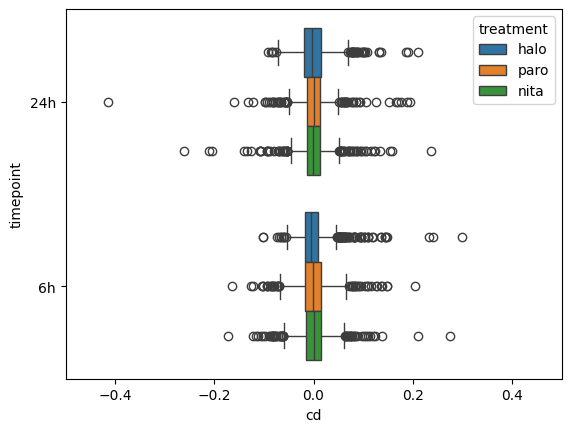

In [89]:
sns.boxplot(df_cd, y = 'timepoint', x = 'cd', hue = 'treatment')
plt.xlim(-0.5, 0.5)

### BioJupies and L1000CDS²

[`BioJupes`](https://maayanlab.cloud/biojupies/upload/table)
Raw counts for 6h Halo and Vehicle control replicates were passed to BioJupies to test for top 'mimic' compounds
    - This uses L1000CDS² search automatically
    - 'Signature' is based off top 2500 most changed genes between control/experimental group using limma R package, based on log10CPM transformed gene expression values


[L1000CDS²](https://maayanlab.cloud/L1000CDS2/#/index)
CD values for 6h Halo passed to oneline L1000CDS² tool, to see if returned 'mimic' compounds were comparable

#### BioJupies

In [56]:
# Set list of tags
list_tags = ['halo', 'vehicle']
list_files = []
for tag in list_tags:
    list_to_append = [file for file in os.listdir(TABULAR) if f'6h_inf_{tag}' in file]
    list_files.extend(list_to_append)

# Initialise dataframe
df_biojupies = pd.DataFrame()

# Iterate through files
for file in list_files:
    # Get filename
    filename = file.split('.')[0]
    # Load data
    df = pd.read_csv(TABULAR + file, sep = '\t')
    # Add column
    df['file'] = filename
    # Concatenate
    df_biojupies = pd.concat([df_biojupies, df])

# Pivot data
df_biojupies = pd.pivot(df_biojupies, index = 'Geneid', columns = 'file', values = 'count')
# Save data
df_biojupies.to_csv(OUTPUT + 'df_biojupies.csv')
# Show data
df_biojupies.head()

file,6h_inf_halo_1,6h_inf_halo_2,6h_inf_halo_3,6h_inf_vehicle_1,6h_inf_vehicle_2,6h_inf_vehicle_3
Geneid,,,,,,
A1BG,52,50,45,53,67,65
A1BG-AS1,11,9,5,13,5,13
A1CF,3,1,0,0,2,3
A2M,5,11,15,2,8,6
A2M-AS1,5,9,5,4,4,0


#### LINCS1000CDS²

In [60]:
# Load data
df_cds = pickle_load(OUTPUT + 'df_cd.pkl')
# Filter data
df_cds = df_cds[(df_cds['treatment'] == 'halo') &
                (df_cds['timepoint'] == '24h')]
# Extract dataframe
df_cds = df_cds[['gene_name', 'cd']]
# Save data
df_cds.to_csv(OUTPUT + 'df_cds.txt', index = False, header = False)
# Show data
df_cds.head()

,gene_name,cd
0,CXCL2,0.210273
1,CCL2,0.190846
2,FOS,0.185441
3,PTGS2,0.135533
4,EGR1,0.132287


#### Compare Results

In [114]:
# Load data
df_bio_result = pd.read_csv(INPUT + 'biojupies_vs_lincs1000cds/biojupies.tsv', sep = '\t')
df_cds_result = pd.read_csv(INPUT + 'biojupies_vs_lincs1000cds/lincs1000cds.tsv', sep = '\t')

# Isolate columns
df_bio_result = df_bio_result[['Rank', 'score', 'Perturbation', 'Cell-line', 'Dose', 'Time']]
df_cds_result = df_cds_result[['Rank', '1-cos(α)', 'Perturbation', 'Cell-line', 'Dose', 'Time']]

# Iterate through results dfs
for df, tag in zip([df_bio_result, df_cds_result], ['bio', 'cds']):
    # Rename columns
    for i, column in enumerate(df.columns[1:]):
        df.rename(columns = {df.columns[i+1] : f'{tag}_{df.columns[i+1]}'}, inplace = True)

# Merge data
df_result = pd.merge(df_bio_result, df_cds_result, how = 'left', on = 'Rank')
# Save data
df_result.to_csv(OUTPUT + 'df_biovscds_result.csv', index = False)

# Show data
df_result.head()

,Rank,bio_score,bio_Perturbation,bio_Cell-line,bio_Dose,bio_Time,cds_1-cos(α),cds_Perturbation,cds_Cell-line,cds_Dose,cds_Time
0,1,0.2143,Narciclasine,HT29,10.0um,6.0h,0.4105,Narciclasine,A549,10.0um,6.0h
1,2,0.2054,Narciclasine,A549,10.0um,6.0h,0.4107,Narciclasine,A375,10.0um,6.0h
2,3,0.1946,Narciclasine,HCC515,10.0um,6.0h,0.4191,EMETINE HYDROCHLORIDE,A549,10.0um,6.0h
3,4,0.1821,EMETINE HYDROCHLORIDE,A549,10.0um,6.0h,0.4201,Narciclasine,HCC515,10.0um,6.0h
4,5,0.1804,Narciclasine,A375,10.0um,24.0h,0.4268,Narciclasine,PC3,10.0um,24.0h


In [93]:
list_timepoint = ['6.0h', '24.0h']

df_result[(df_result['bio_Cell-line'] == 'HT29') &
          (df_result['bio_Time'].isin(list_timepoint)) &
          (df_result['bio_Dose'] == '10.0um')]

,Rank,bio_score,bio_Perturbation,bio_Cell-line,bio_Dose,bio_Time,cds_1-cos(α),cds_Perturbation,cds_Cell-line,cds_Dose,cds_Time
0,1,0.2143,Narciclasine,HT29,10.0um,6.0h,0.4105,Narciclasine,A549,10.0um,6.0h
10,11,0.1554,Narciclasine,HT29,10.0um,24.0h,0.4474,homoharringtonine,PC3,10.0um,24.0h
15,16,0.1518,BRD-K91370081,HT29,10.0um,6.0h,0.4600,Homoharringtonine,PC3,10.0um,24.0h
27,28,0.1411,BRD-K04853698,HT29,10.0um,6.0h,0.4808,Narciclasine,MCF7,10.0um,6.0h
35,36,0.1357,BRD-K76674262,HT29,10.0um,6.0h,0.4920,homoharringtonine,HCC515,10.0um,6.0h
38,39,0.1339,homoharringtonine,HT29,10.0um,6.0h,0.4952,Narciclasine,H1299,10.0um,6.0h


## STRING

### Edges

In [95]:
# Load data
string_edges = pd.read_csv(STRING_EDGES, compression = 'gzip', sep = ' ')
# Show data
string_edges.head()

,protein1,protein2,homology,experiments,experiments_transferred,database,database_transferred,textmining,textmining_transferred,combined_score
0,9606.ENSP00000000233,9606.ENSP00000257770,0,312,0,0,0,0,0,311
1,9606.ENSP00000000233,9606.ENSP00000226004,0,162,0,0,0,0,0,161
2,9606.ENSP00000000233,9606.ENSP00000434442,0,0,0,500,0,0,0,499
3,9606.ENSP00000000233,9606.ENSP00000262455,0,531,0,0,0,0,0,531
4,9606.ENSP00000000233,9606.ENSP00000303145,0,0,0,500,0,0,0,499


### Info

In [96]:
# Load data
string_info = pd.read_csv(STRING_INFO, compression = 'gzip', sep = '\t')
# Show data
string_info.head()

,#string_protein_id,preferred_name,protein_size,annotation
0,9606.ENSP00000000233,ARF5,180,ADP-ribosylation factor 5; GTP-binding protein...
1,9606.ENSP00000000412,M6PR,277,Cation-dependent mannose-6-phosphate receptor;...
2,9606.ENSP00000001008,FKBP4,459,"Peptidyl-prolyl cis-trans isomerase FKBP4, N-t..."
3,9606.ENSP00000001146,CYP26B1,512,Cytochrome P450 26B1; Involved in the metaboli...
4,9606.ENSP00000002125,NDUFAF7,441,"Protein arginine methyltransferase NDUFAF7, mi..."


### `df_string`

In [97]:
# Variables
source_column = 'protein1'
target_column = 'protein2'
score_column = 'combined_score'
id_column = '#string_protein_id'
taxon_id = '9606.'

In [98]:
# Copy edgelist
df_string = string_edges.copy(deep = True)
# Isolate columns
df_string = df_string[[source_column, target_column, score_column]]

# Rename columns for merge
string_info.rename(columns = {id_column : source_column}, inplace = True)
# Merge
df_string = pd.merge(df_string, string_info[[source_column, 'preferred_name', 'annotation']], how = 'left', on = source_column)
# Rename columns for merge
string_info.rename(columns = {source_column : target_column}, inplace = True)
# Merge
df_string = pd.merge(df_string, string_info[[target_column, 'preferred_name', 'annotation']], how = 'left', on = target_column)
# Reset column names
string_info.rename(columns = {target_column : id_column}, inplace = True)

# Rename columns
old_names = df_string.columns
new_names = ['source_id', 'target_id', 'weight', 'source', 'source_annot', 'target', 'target_annot']
df_string.rename(columns = dict(zip(old_names, new_names)), inplace = True)

# Remove taxon ID
for column in ['source_id', 'target_id']:
    df_string[column] = df_string[column].str.replace(taxon_id, '')

# Set column order
column_order = ['source', 'target', 'weight', 'source_id', 'target_id', 'source_annot', 'target_annot']
df_string = df_string[column_order]

# Save data
df_string.to_csv(OUTPUT + 'df_string.csv', index = False)

# Show data
df_string.head()

,source,target,weight,source_id,target_id,source_annot,target_annot
0,ARF5,NT5E,311,ENSP00000000233,ENSP00000257770,ADP-ribosylation factor 5; GTP-binding protein...,5'-nucleotidase; Hydrolyzes extracellular nucl...
1,ARF5,DUSP3,161,ENSP00000000233,ENSP00000226004,ADP-ribosylation factor 5; GTP-binding protein...,Dual specificity protein phosphatase 3; Shows ...
2,ARF5,ARFGAP2,499,ENSP00000000233,ENSP00000434442,ADP-ribosylation factor 5; GTP-binding protein...,ADP-ribosylation factor GTPase-activating prot...
3,ARF5,ERP44,531,ENSP00000000233,ENSP00000262455,ADP-ribosylation factor 5; GTP-binding protein...,Endoplasmic reticulum resident protein 44; Med...
4,ARF5,TMED10,499,ENSP00000000233,ENSP00000303145,ADP-ribosylation factor 5; GTP-binding protein...,Transmembrane emp24 domain-containing protein ...


### Base Graph

In [100]:
# Variables
score_filter = 0

In [101]:
# Load data
df_string = pd.read_csv(OUTPUT + 'df_string.csv')
# Generate graph object
graph_base = nx.from_pandas_edgelist(df_string[df_string.columns[0:3]], source = 'source', target = 'target', edge_attr = 'weight')

# Record number of nodes and edges
num_nodes = len(graph_base.nodes)
num_edges = len(graph_base.edges)

# Filter by edge weights
graph_base.remove_edges_from([(source, target) for source, target, weight in graph_base.edges(data = 'weight') if weight < score_filter])
# Remove unconnected nodes
graph_base.remove_nodes_from(list(nx.isolates(graph_base)))

# Record number of nodes and edges
num_nodes_filter = len(graph_base.nodes)
num_edges_filter = len(graph_base.edges)
# Calculate variables
percent_nodes = num_nodes_filter / num_nodes * 100
percent_edges = num_edges_filter / num_edges * 100

# Report
print(f'Base graph of {num_nodes:,} nodes and {num_edges:,} edges generated')
print(f'Filtered for edges with a confidence score >= {score_filter}')
print(f'{percent_nodes:.2f}% nodes ({num_nodes_filter:,}/{num_nodes:,}) and {percent_edges:.2f}% edges ({num_edges_filter:,}/{num_edges:,}) remain')
print()

# Save graph
pickle_save(OUTPUT + 'graph_base.pkl', graph_base)
# with open(GRAPH_OUT / 'graph_base.pkl', 'wb') as f:
#     pickle.dump(graph_base, f)

Base graph of 18,767 nodes and 738,805 edges generated
Filtered for edges with a confidence score >= 0
100.00% nodes (18,767/18,767) and 100.00% edges (738,805/738,805) remain



### Landmark Graph

A graph generated using only the landmark genes identified in RNAseq experimental data

In [104]:
# Load graph
with open(OUTPUT + 'graph_base.pkl', 'rb') as f:
    graph_base = pickle.load(f)

# Load data
list_landmark = file_to_list(OUTPUT + 'mapped_landmark.txt')
#df_lincs_landmark = pd.read_csv(OUTPUT + 'df_lincs_landmark.csv')

# Extract landmark gene IDs
#list_landmark = list(pd.unique(df_lincs_landmark['gene_name']))
# Extract nodelist
list_nodes = list(graph_base.nodes)
# Get landmark nodes not found in graph_base
list_missing = set(list_landmark) - set(list_nodes)
# Get overlapping landmark genes
list_overlap = set(list_landmark).intersection(set(list_nodes))

# Set nodes to remove
list_remove = set(list_nodes) - set(list_landmark)
# Copy graph
graph_lm = graph_base.copy()
# Remove nodes
graph_lm.remove_nodes_from(list_remove)
# Extract isolated nodes
list_isolates = list(nx.isolates(graph_lm))
# Remove unconnected nodes
graph_lm.remove_nodes_from(list_isolates)

# Calculate variables
len_landmark = len(list_landmark)
len_missing = len(list_missing)
len_overlap = len(list_overlap)
len_nodes = len(graph_base.nodes)
len_nodes_lm = len(graph_lm.nodes)
len_isolates = len(list_isolates)
percent_missing = len_missing / len_landmark * 100 
percent_overlap = len_overlap / len_landmark * 100
percent_isolates = len_isolates / len_overlap * 100
percent_nodes = len_nodes_lm / len_nodes * 100
percent_landmark = len_nodes_lm / len_landmark * 100

# Report
print(f'{len_landmark:,} landmark genes identified')
print(f'{percent_overlap:.2f}% of landmark genes ({len_overlap:,}/{len_landmark:,}) found in graph_base')
print(f'{percent_isolates:.2f}% of landmark genes ({len_isolates:,}/{len_overlap:,}) in subgraph found as isolates')
print(f'{percent_nodes:.2f}% of nodes ({len_nodes_lm:,}/{len_nodes:,}) remain after filtering graph_base for landmark nodes and removing isolates')
print(f'{percent_landmark:.2f}% of landmark genes ({len_nodes_lm:,}/{len_landmark:,}) retained in graph_lm')

# Save graph
pickle_save(OUTPUT + 'graph_lm.pkl', graph_lm)
# with open(GRAPH_OUT / 'graph_lm.pkl', 'wb') as f:
#     pickle.dump(graph_lm, f)

945 landmark genes identified
99.79% of landmark genes (943/945) found in graph_base
2.97% of landmark genes (28/943) in subgraph found as isolates
4.88% of nodes (915/18,767) remain after filtering graph_base for landmark nodes and removing isolates
96.83% of landmark genes (915/945) retained in graph_lm


In [ ]:
# Extract landmark genes missing from graph_base
#df_missing = df_lincs_landmark[df_lincs_landmark['gene_name'].isin(list_missing)].reset_index(drop = True)
list_missing = [gene for gene in list_landmark if gene in list_missing]
# Extract landmark data for isolates
#df_isolates = df_lincs_landmark[df_lincs_landmark['gene_name'].isin(list_isolates)].reset_index(drop = True)
list_isolates = [gene for gene in list_landmark if gene in list_isolates]

# # Drop columns
# for df in [df_missing, df_isolates]:
#     df.drop(columns = ['landmark', 'inferred'], inplace = True)

# Save data
list_to_file(OUTPUT + 'list_missing.txt', list_missing)
list_to_file(OUTPUT + 'list_isolates.txt', list_isolates)

# df_missing.to_csv(OUTPUT + 'df_missing.csv', index = False)
# df_isolates.to_csv(OUTPUT + 'df_isolates.csv', index = False)

# Show data
# df_isolates.head()

2
28


### Context Graphs

In [6]:
# Load graph
graph_lm = pickle_load(OUTPUT + 'graph_lm.pkl')

In [172]:
# Load data
df_cd = pickle_load(OUTPUT + 'df_cd.pkl')
df_cd['cell_line'] = 'COLO-680N'
df_cd.rename(columns = {'treatment' : 'perturbagen_name'}, inplace = True)
df_cd['timepoint'] = df_cd['timepoint'].str.upper()

list_perts = ['halo', 'nita', 'paro']
list_doses = ['20.85', '15.4', '9.72']

# Dose column
df_cd['dose'] = ''
# Iterate through perts and doses
for pert, dose in zip(list_perts, list_doses):
    df_cd.loc[df_cd['perturbagen_name'] == pert, 'dose'] = dose

# Load gene descriptions
df_genes = pickle_load(OUTPUT + 'df_lincs_genes.pkl')
# Merge data
df_cd = pd.merge(df_cd, df_genes[['gene_name', 'gene_desc']], how = 'left', on = 'gene_name')

# Show data
#df_genes.head()
df_cd.head()

,cd,gene_name,datatype,perturbagen_name,timepoint,cell_line,dose,gene_desc
0,0.210273,CXCL2,inf,halo,24H,COLO-680N,20.85,chemokine (C-X-C motif) ligand 2
1,0.190846,CCL2,inf,halo,24H,COLO-680N,20.85,chemokine (C-C motif) ligand 2
2,0.185441,FOS,inf,halo,24H,COLO-680N,20.85,FBJ murine osteosarcoma viral oncogene homolog
3,0.135533,PTGS2,inf,halo,24H,COLO-680N,20.85,prostaglandin-endoperoxide synthase 2
4,0.132287,EGR1,inf,halo,24H,COLO-680N,20.85,early growth response 1


In [ ]:
# Load data
df_lincs_filter = pickle_load(OUTPUT + 'df_lincs_filter.pkl')

# Copy
df_lincs = df_lincs_filter.copy()
# Drop column
df_lincs.drop(columns = 'cid', inplace = True)

## DROPPING DUPLICATES FOR VISUALISATION (following commented cells are tests for dupes)
df_lincs.drop_duplicates(subset = ['dataset', 'perturbagen_name', 'dose', 'timepoint', 'gene_id', 'gene_name', 'gene_desc'], inplace = True)

# Pivot
df_lincs = pd.pivot(df_lincs, index = ['perturbagen_id', 'perturbagen_name', 'dose', 'timepoint', 'gene_id', 'gene_name', 'gene_desc'], columns = 'dataset', values = 'cd')
# Get non-NaN CD value
df_lincs['cd'] = df_lincs[df_lincs.columns].bfill(axis = 1).iloc[:, 0]
# Drop columns
df_lincs.drop(columns = df_lincs.columns[:-1], inplace = True)
# Reset index
df_lincs.reset_index(inplace = True)
# Add column
df_lincs['cell_line'] = 'HT29'

# Show data
df_lincs.head()

dataset,perturbagen_id,perturbagen_name,dose,timepoint,gene_id,gene_name,gene_desc,cd,cell_line
0,BRD-A02189320,met-leu-phe,10,24H,23,ABCF1,ATP binding cassette subfamily F member 1,-0.695600,HT29
1,BRD-A02189320,met-leu-phe,10,24H,25,ABL1,"ABL proto-oncogene 1, non-receptor tyrosine ki...",-0.808115,HT29
2,BRD-A02189320,met-leu-phe,10,24H,30,ACAA1,acetyl-CoA acyltransferase 1,0.215947,HT29
3,BRD-A02189320,met-leu-phe,10,24H,39,ACAT2,acetyl-CoA acetyltransferase 2,-0.233740,HT29
4,BRD-A02189320,met-leu-phe,10,24H,47,ACLY,ATP citrate lyase,-0.190705,HT29


In [ ]:
# dupes = df_lincs[df_lincs.duplicated(subset = ['perturbagen_id', 'perturbagen_name', 'dose', 'timepoint', 'gene_id', 'gene_name', 'gene_desc'], keep = False)]
# dupes

In [ ]:
# dupes = (
#     df_lincs.groupby(['perturbagen_name', 'dose', 'timepoint', 'gene_id', 'gene_name', 'gene_desc'])
#     .size()
#     .reset_index(name='count')
#     .query('count > 1')
# )

# dupes

In [ ]:
# test = df_lincs[(df_lincs['perturbagen_name'] == 'BMS-191011') &
#          (df_lincs['timepoint'] == '6H') &
#          (df_lincs['gene_name'] == 'ABCF1')]

# test

In [239]:
list_cols = ['cell_line', 'perturbagen_name', 'dose', 'timepoint', 'gene_name', 'gene_desc', 'cd']

df_cd_attr = df_cd[list_cols].copy()
df_lincs_attr = df_lincs[list_cols].copy()

# Merge data
#df_attributes = pd.concat([df_cd[list_cols], df_lincs[list_cols]])

# Show data
#df_attributes.head()

In [240]:
# Iterate through dataframes
for df in tqdm([df_cd_attr, df_lincs_attr], desc = 'Iterating through dataframes', total = 2):
    # Define unique variable lists
    unique_cells = list(pd.unique(df['cell_line']))
    unique_perturbagens = list(pd.unique(df['perturbagen_name']))
    unique_timepoints = list(pd.unique(df['timepoint']))
    unique_doses = list(pd.unique(df['dose']))

    # Iterate through combinations of unique values
    for cell_line, perturbagen_name, dose, timepoint in tqdm(itertools.product(unique_cells, unique_perturbagens, unique_doses, unique_timepoints), desc = 'Generating context graphs'):

        # Slice data
        df_slice = df[(df['cell_line'] == cell_line) &
                      (df['perturbagen_name'] == perturbagen_name) &
                      (df['dose'] == dose) &
                      (df['timepoint'] == timepoint)]
        
        # Check df_slice
        if len(df_slice) > 0:

            # Set index
            df_slice.set_index('gene_name', inplace = True)

            # Extract columns
            df_slice = df_slice[['cd']]

            # Copy graph_lm
            graph_slice = graph_lm.copy()
            # Set node attributes
            nx.set_node_attributes(graph_slice, df_slice['cd'].to_dict(), name = 'cd')

            # Save graph
            pickle_save(CONTEXT + f'{cell_line}_{perturbagen_name}_{dose}_{timepoint}.pkl', graph_slice)

Generating context graphs: 18it [00:00, 122.61it/s][00:00<?, ?it/s]
Generating context graphs: 988it [02:33,  6.42it/s][00:00<00:00,  6.68it/s]
Iterating through dataframes: 100%|██████████| 2/2 [02:34<00:00, 77.11s/it]


In [236]:
# Define unique variable lists
unique_cells = list(pd.unique(df_attributes['cell_line']))
unique_perturbagens = list(pd.unique(df_attributes['perturbagen_name']))
unique_timepoints = list(pd.unique(df_attributes['timepoint']))
unique_doses = list(pd.unique(df_attributes['dose']))

In [ ]:
# Iterate through combinations of unique values
for cell_line, perturbagen_name, dose, timepoint in itertools.product(unique_cells, unique_perturbagens, unique_doses, unique_timepoints):

    # Slice data
    df_slice = df_attributes[(df_attributes['cell_line'] == cell_line) &
                             (df_attributes['perturbagen_name'] == perturbagen_name) &
                             (df_attributes['dose'] == dose) &
                             (df_attributes['timepoint'] == timepoint)]
    
    # Check df_slice
    if len(df_slice) > 0:

        # Set index
        df_slice.set_index('gene_name', inplace = True)

        # Extract columns
        df_slice = df_slice[['cd']]

        # Copy graph_lm
        graph_slice = graph_lm.copy()
        # Set node attributes
        nx.set_node_attributes(graph_slice, df_slice['cd'].to_dict(), name = 'cd')

        # Save graph
        pickle_save(CONTEXT + f'{cell_line}_{perturbagen_name}_{dose}_{timepoint}.pkl', graph_slice)
    # with open(GRAPH_OUT / f'{cell_line}_{perturbagen_name}_{dose}_{timepoint}.pkl', 'wb') as f:
    #     pickle.dump(graph_slice, f)

In [ ]:
# Iterate through combinations of unique values
for cell_line, perturbagen_name, dose, timepoint in itertools.product(unique_cells, unique_perturbagens, unique_doses, unique_timepoints):
    print(cell_line, perturbagen_name, dose, timepoint)

# Analysis

## Graph List